In [67]:
import re
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})


def parse_results(filename):
    """Parse a results log file.
    
    Returns dict keyed by (config_str, n) with values:
        {'comp': [times], 'exchange': [times], 'global_comm': [times]}
    where each list has one entry per process (averaged later).
    """
    results = {}
    current_key = None

    with open(filename, 'r') as f:
        for line in f:
            # Match header: ===Config: 1 4, Size: 100x100 ===
            m = re.match(r'===Config: (\d+ \d+), Size: (\d+)x\d+', line)
            if m:
                config, n = m.group(1), int(m.group(2))
                current_key = (config, n)
                results[current_key] = {'comp': [], 'exchange': [], 'global_comm': []}
                continue

            if current_key is None:
                continue

            m = re.match(r'\(\d+\) Computation:\s+([\d.]+) s', line)
            if m:
                results[current_key]['comp'].append(float(m.group(1)))
            m = re.match(r'\(\d+\) Exchange:\s+([\d.]+) s', line)
            if m:
                results[current_key]['exchange'].append(float(m.group(1)))
            m = re.match(r'\(\d+\) Global comm:\s+([\d.]+) s', line)
            if m:
                results[current_key]['global_comm'].append(float(m.group(1)))

    # Average across processes
    out = {}
    for key, vals in results.items():
        out[key] = {
            'comp': np.mean(vals['comp']),
            'exchange': np.mean(vals['exchange']),
            'global_comm': np.mean(vals['global_comm']),
        }
    return out


# Test it
data = parse_results('results_p4_sizes.log')
for (config, n), vals in sorted(data.items(), key=lambda x: (x[0][0], x[0][1])):
    print(f"Config {config}, n={n:>4}: comp={vals['comp']:.6f}  exchange={vals['exchange']:.6f}")

Config 1 4, n=  10: comp=0.000022  exchange=0.000186
Config 1 4, n=  15: comp=0.000065  exchange=0.000232
Config 1 4, n=  20: comp=0.000155  exchange=0.000252
Config 1 4, n=  30: comp=0.000496  exchange=0.000411
Config 1 4, n=  50: comp=0.002080  exchange=0.000577
Config 1 4, n=  75: comp=0.007048  exchange=0.000962
Config 1 4, n= 100: comp=0.016665  exchange=0.001266
Config 2 2, n=  10: comp=0.000024  exchange=0.000238
Config 2 2, n=  15: comp=0.000063  exchange=0.000279
Config 2 2, n=  20: comp=0.000148  exchange=0.000341
Config 2 2, n=  30: comp=0.000509  exchange=0.000471
Config 2 2, n=  50: comp=0.002144  exchange=0.000831
Config 2 2, n=  75: comp=0.007065  exchange=0.001256
Config 2 2, n= 100: comp=0.015824  exchange=0.001380


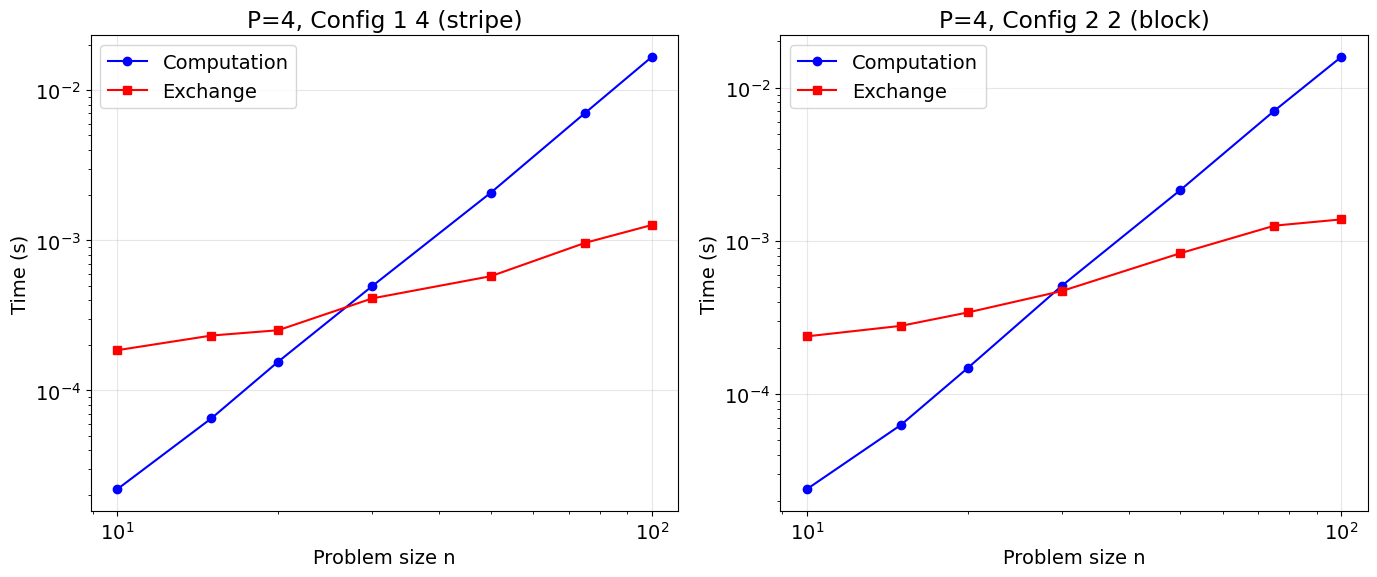

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, config in zip(axes, ["1 4", "2 2"]):
    subset = {n: vals for (cfg, n), vals in data.items() if cfg == config}
    ns = sorted(subset.keys())
    comps = [subset[n]['comp'] for n in ns]
    exchanges = [subset[n]['exchange'] for n in ns]

    ax.loglog(ns, comps, 'bo-', label='Computation')
    ax.loglog(ns, exchanges, 'rs-', label='Exchange')
    ax.set_xlabel('Problem size n')
    ax.set_ylabel('Time (s)')
    ax.set_title(f'P=4, Config {config} ({"stripe" if config == "1 4" else "block"})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('crossover_p4.pdf')
plt.show()

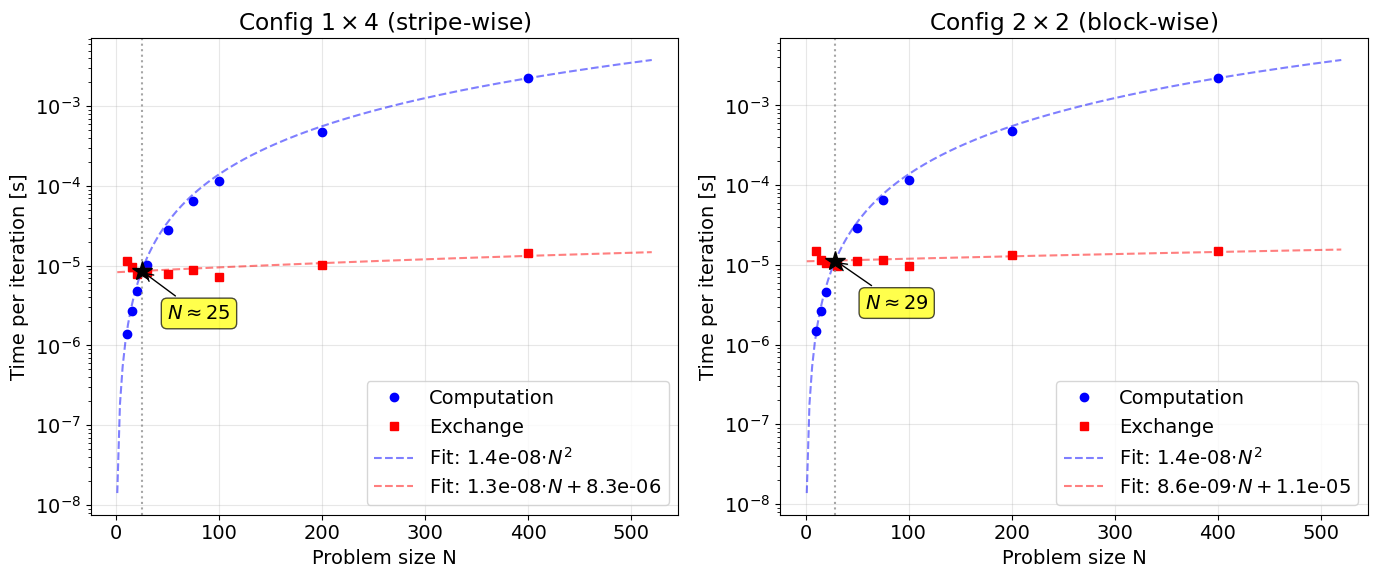

In [69]:
# Iteration counts until convergence from the data
iters = {10: 16, 15: 24, 20: 32, 30: 49, 50: 74, 75: 109, 100: 141, 200: 274, 400: 529}

from scipy.optimize import nnls

# Merge data from 4_5 (small N) and 4_2 (larger N)
data_42 = parse_results('../4_2/results.log')
data_all = {**data, **data_42}

fit_results = {}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, config in zip(axes, ["1 4", "2 2"]):
    subset = {n: vals for (cfg, n), vals in data_all.items() if cfg == config}
    ns = sorted(subset.keys())
    comps_per_iter = np.array([subset[n]['comp'] / iters[n] for n in ns])
    exchs_per_iter = np.array([subset[n]['exchange'] / iters[n] for n in ns])
    ns = np.array(ns)

    # Plot data points
    ax.semilogy(ns, comps_per_iter, 'bo', label='Computation', markersize=6)
    ax.semilogy(ns, exchs_per_iter, 'rs', label='Exchange', markersize=6)

    # Fit comp/iter: a * N^2 + b
    A_comp = np.column_stack([ns**2, np.ones_like(ns)])
    (a_comp, b_comp), _ = nnls(A_comp, comps_per_iter)

    # Fit exch/iter: alpha * N + beta  (non-negative: latency and bandwidth >= 0)
    A_exch = np.column_stack([ns, np.ones_like(ns)])
    (alpha, beta), _ = nnls(A_exch, exchs_per_iter)

    fit_results[config] = [a_comp, alpha, beta]

    # Plot fits
    n_fit = np.linspace(1, ns.max() * 1.3, 200)
    ax.semilogy(n_fit, a_comp * n_fit**2 + b_comp, 'b--', alpha=0.5, label=rf'Fit: {a_comp:.1e}$\cdot N^2$')
    ax.semilogy(n_fit, alpha * n_fit + beta, 'r--', alpha=0.5, label=rf'Fit: {alpha:.1e}$\cdot N +${beta:.1e}')

    # Crossover: a*N^2 + b = alpha*N + beta => a*N^2 - alpha*N + (b - beta) = 0
    roots = np.roots([a_comp, -alpha, b_comp - beta])
    real_pos = [r.real for r in roots if np.isreal(r) and r.real > 0]
    if real_pos:
        n_cross = min(real_pos)
        t_cross = alpha * n_cross + beta
        ax.axvline(x=n_cross, color='gray', linestyle=':', alpha=0.7)
        ax.plot(n_cross, t_cross, 'k*', markersize=15, zorder=5)
        ax.annotate(rf'$N \approx {n_cross:.0f}$', xy=(n_cross, t_cross),
                    xytext=(n_cross * 2, t_cross / 4),
                    arrowprops=dict(arrowstyle='->', color='black'),
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

    ax.set_xlabel('Problem size N')
    ax.set_ylabel('Time per iteration [s]')
    ax.set_title(rf'Config ${config[0]} \times {config[-1]}$ ({"stripe-wise" if config == "1 4" else "block-wise"})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('crossover_p4.pdf')
plt.show()

In [ ]:
def estimate_p(a_comp, alpha, beta, N):
    delta = np.sqrt(alpha**2 + 4 * beta * a_comp)
    sqrt_p = (delta - alpha) * N / (2 * beta)
    return sqrt_p ** 2

p = 4       # total number of processes
N = 1000    # grid size

for config in ["2 2", "1 4"]:
    a_comp = fit_results[config][0] * p
    alpha = fit_results[config][1] * np.sqrt(p)
    beta = fit_results[config][2]

    p_est = estimate_p(a_comp, alpha, beta, N)
    print(f"Grid topology {p}{config[0]}{config[-1]} - Estimated p={p_est:.2f}")

Grid topology 422 - Estimated p=4846.78
Grid topology 414 - Estimated p=6549.05
